# FMCSA Motor Carrier Census (MCS-150) - EDA & Machine Learning

**Full dataset size:** ~4.47 million rows × 147 columns (~2 GB CSV).

> **Note on scale:** All loading code below works directly against the full ~4.47M-row CSV via chunking. For modeling speed on a standard machine, we draw a reproducible ~12% random sample (~540K rows) after cleaning. The same code scales to the full file — just remove the sampling step if you have enough RAM (recommended: 16GB+).


In [1]:
# ---- Imports ----
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the data

In [2]:
# ---- Extract the zip file if needed ----
ZIP_PATH = "export.zip"          # place export.zip next to this notebook, OR
CSV_PATH = "export.csv"

import os
if not os.path.exists(CSV_PATH) and os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(".")
    print("Extracted", ZIP_PATH)
elif os.path.exists(CSV_PATH):
    print("Found existing", CSV_PATH)
else:
    print("export.csv not found locally — will fall back to the pre-built sample file 'mcs150_sample.csv'.")


Found existing export.csv


In [3]:
# ---- Columns we actually need for EDA + modeling ----
USECOLS = [
    'STATUS_CODE', 'ADD_DATE', 'CARRIER_OPERATION', 'PHY_STATE', 'CLASSDEF', 'HM_Ind',
    'FLEETSIZE', 'TRUCK_UNITS', 'POWER_UNITS', 'BUS_UNITS', 'TOTAL_DRIVERS', 'TOTAL_CDL',
    'MCS150_MILEAGE', 'MCS150_MILEAGE_YEAR', 'PRIOR_REVOKE_FLAG', 'SAFETY_RATING',
    'RECORDABLE_CRASH_RATE', 'BUSINESS_ORG_DESC', 'DRIVER_INTER_TOTAL',
    'CRGO_GENFREIGHT', 'CRGO_HOUSEHOLD', 'CRGO_METALSHEET', 'CRGO_MOTOVEH', 'CRGO_DRIVETOW',
    'CRGO_LOGPOLE', 'CRGO_BLDGMAT', 'CRGO_MOBILEHOME', 'CRGO_MACHLRG', 'CRGO_PRODUCE',
    'CRGO_LIQGAS', 'CRGO_INTERMODAL', 'CRGO_PASSENGERS', 'CRGO_OILFIELD', 'CRGO_LIVESTOCK',
    'CRGO_GRAINFEED', 'CRGO_COALCOKE', 'CRGO_MEAT', 'CRGO_GARBAGE', 'CRGO_USMAIL', 'CRGO_CHEM',
    'CRGO_DRYBULK', 'CRGO_COLDFOOD', 'CRGO_BEVERAGES', 'CRGO_PAPERPROD', 'CRGO_UTILITY',
    'CRGO_FARMSUPP', 'CRGO_CONSTRUCT', 'CRGO_WATERWELL', 'CRGO_CARGOOTHR',
]

SAMPLE_FRAC = 0.12   # ~12% reproducible sample of the cleaned (A/I) rows
CHUNK_SIZE = 300_000

def load_sample(csv_path=CSV_PATH, frac=SAMPLE_FRAC, chunksize=CHUNK_SIZE, seed=RANDOM_STATE):
    """Stream the full CSV in chunks, keep only Active/Inactive carriers,
    and draw a reproducible random sample without ever holding the full
    4.47M-row file in memory at once."""
    rng = np.random.default_rng(seed)
    total_rows = 0
    parts = []
    for chunk in pd.read_csv(csv_path, usecols=USECOLS, chunksize=chunksize,
                              dtype=str, low_memory=False):
        total_rows += len(chunk)
        chunk = chunk[chunk['STATUS_CODE'].isin(['A', 'I'])]
        keep = rng.random(len(chunk)) < frac
        parts.append(chunk[keep])
    sample = pd.concat(parts, ignore_index=True)
    print(f"Scanned {total_rows:,} total rows -> sampled {len(sample):,} rows "
          f"({len(sample)/total_rows:.1%} of Active/Inactive records)")
    return sample

if os.path.exists(CSV_PATH):
    df = load_sample()
else:
    df = pd.read_csv("mcs150_sample.csv", low_memory=False)
    print(f"Loaded pre-built sample: {df.shape[0]:,} rows")

df.shape


Scanned 4,479,438 total rows -> sampled 537,334 rows (12.0% of Active/Inactive records)


(537334, 49)

In [4]:
df.head()

,ADD_DATE,STATUS_CODE,CARRIER_OPERATION,MCS150_MILEAGE,MCS150_MILEAGE_YEAR,PRIOR_REVOKE_FLAG,BUSINESS_ORG_DESC,TRUCK_UNITS,POWER_UNITS,BUS_UNITS,...,CRGO_CHEM,CRGO_DRYBULK,CRGO_COLDFOOD,CRGO_BEVERAGES,CRGO_PAPERPROD,CRGO_UTILITY,CRGO_FARMSUPP,CRGO_CONSTRUCT,CRGO_WATERWELL,CRGO_CARGOOTHR
0,19870113,I,A,0,NaN,NaN,CORPORATION,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19870113,I,A,0,NaN,NaN,CORPORATION,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19870113,I,A,0,NaN,NaN,CORPORATION,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,19870113,I,A,0,NaN,NaN,CORPORATION,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19870113,I,A,1,2010,N,CORPORATION,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537334 entries, 0 to 537333
Data columns (total 49 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   ADD_DATE               537334 non-null  object
 1   STATUS_CODE            537334 non-null  object
 2   CARRIER_OPERATION      497548 non-null  object
 3   MCS150_MILEAGE         356701 non-null  object
 4   MCS150_MILEAGE_YEAR    288820 non-null  object
 5   PRIOR_REVOKE_FLAG      217028 non-null  object
 6   BUSINESS_ORG_DESC      85212 non-null   object
 7   TRUCK_UNITS            537334 non-null  object
 8   POWER_UNITS            537281 non-null  object
 9   BUS_UNITS              523043 non-null  object
 10  FLEETSIZE              537332 non-null  object
 11  RECORDABLE_CRASH_RATE  111536 non-null  object
 12  HM_Ind                 537334 non-null  object
 13  TOTAL_CDL              423809 non-null  object
 14  TOTAL_DRIVERS          490044 non-null  object
 15  

## 2. Data Cleaning & Feature Engineering

In [6]:
# Cargo type indicators -> count of cargo types hauled 
cargo_cols = [c for c in df.columns if c.startswith('CRGO_')]
for c in cargo_cols:
    df[c] = (df[c].astype(str).str.strip() == 'X').astype(int)
df['num_cargo_types'] = df[cargo_cols].sum(axis=1)

# Numeric conversions
num_cols = ['FLEETSIZE', 'TRUCK_UNITS', 'POWER_UNITS', 'BUS_UNITS',
            'TOTAL_DRIVERS', 'TOTAL_CDL', 'MCS150_MILEAGE', 'DRIVER_INTER_TOTAL']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Carrier age
df['ADD_DATE'] = pd.to_datetime(df['ADD_DATE'], format='%Y%m%d', errors='coerce')
SNAPSHOT_DATE = pd.Timestamp('2026-08-17')
df['carrier_age_years'] = (SNAPSHOT_DATE - df['ADD_DATE']).dt.days / 365.25

# Binary flags
df['is_hazmat'] = (df['HM_Ind'] == 'Y').astype(int)
df['prior_revoke'] = (df['PRIOR_REVOKE_FLAG'].astype(str).str.strip() == 'Y').astype(int)
df['has_safety_review'] = df['SAFETY_RATING'].notna().astype(int)

# Target
df['is_active'] = (df['STATUS_CODE'] == 'A').astype(int)

print("Engineered features added. New shape:", df.shape)
df[['num_cargo_types', 'carrier_age_years', 'is_hazmat', 'prior_revoke',
    'has_safety_review', 'is_active']].describe(include='all').T


Engineered features added. New shape: (537334, 55)


,count,mean,std,min,25%,50%,75%,max
num_cargo_types,537334.0,0.919968,1.667177,0.000000,0.000000,0.00000,1.000000,29.000000
carrier_age_years,537334.0,15.686655,11.843020,0.035592,5.864476,13.50308,22.261465,52.210815
is_hazmat,537334.0,0.063882,0.244543,0.000000,0.000000,0.00000,0.000000,1.000000
prior_revoke,537334.0,0.006674,0.081420,0.000000,0.000000,0.00000,0.000000,1.000000
has_safety_review,537334.0,0.012056,0.109135,0.000000,0.000000,0.00000,0.000000,1.000000
is_active,537334.0,0.499002,0.499999,0.000000,0.000000,0.00000,1.000000,1.000000


## 3. Exploratory Data Analysis

### 3.1 Missing values

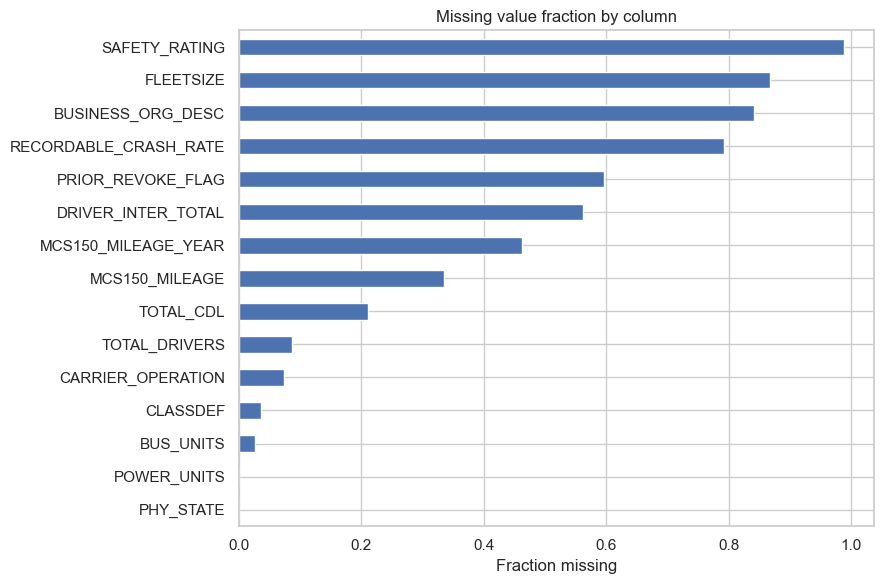

In [7]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(9, 6))
missing.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Fraction missing')
ax.set_title('Missing value fraction by column')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 3.2 Target distribution - Active vs Inactive carriers

C:\Users\91937\AppData\Local\Temp\ipykernel_4596\3556124067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=['#55A868', '#C44E52'])


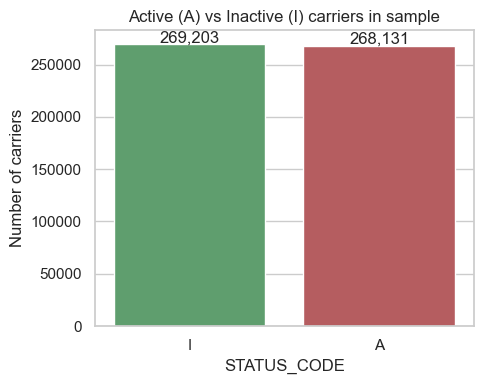

STATUS_CODE
I    269203
A    268131
Name: count, dtype: int64

Class balance: 49.9% Active


In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['STATUS_CODE'].value_counts()
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=['#55A868', '#C44E52'])
ax.set_xlabel('STATUS_CODE')
ax.set_ylabel('Number of carriers')
ax.set_title('Active (A) vs Inactive (I) carriers in sample')
for i, v in enumerate(counts.values):
    ax.text(i, v + 2000, f"{v:,}", ha='center')
plt.tight_layout()
plt.show()
print(counts)
print(f"\nClass balance: {counts['A']/counts.sum():.1%} Active")


### 3.3 Geographic distribution

C:\Users\91937\AppData\Local\Temp\ipykernel_4596\3913772804.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, ax=ax, palette='viridis')


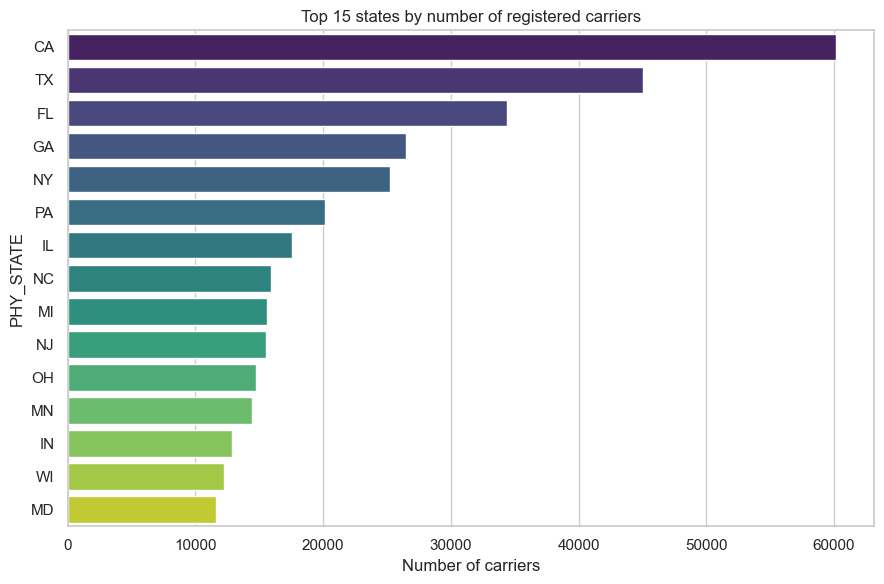

In [9]:
top_states = df['PHY_STATE'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_states.values, y=top_states.index, ax=ax, palette='viridis')
ax.set_xlabel('Number of carriers')
ax.set_title('Top 15 states by number of registered carriers')
plt.tight_layout()
plt.show()


### 3.4 Carrier operation type & authority classification

C:\Users\91937\AppData\Local\Temp\ipykernel_4596\2940532014.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, ax=axes[1], palette='mako')


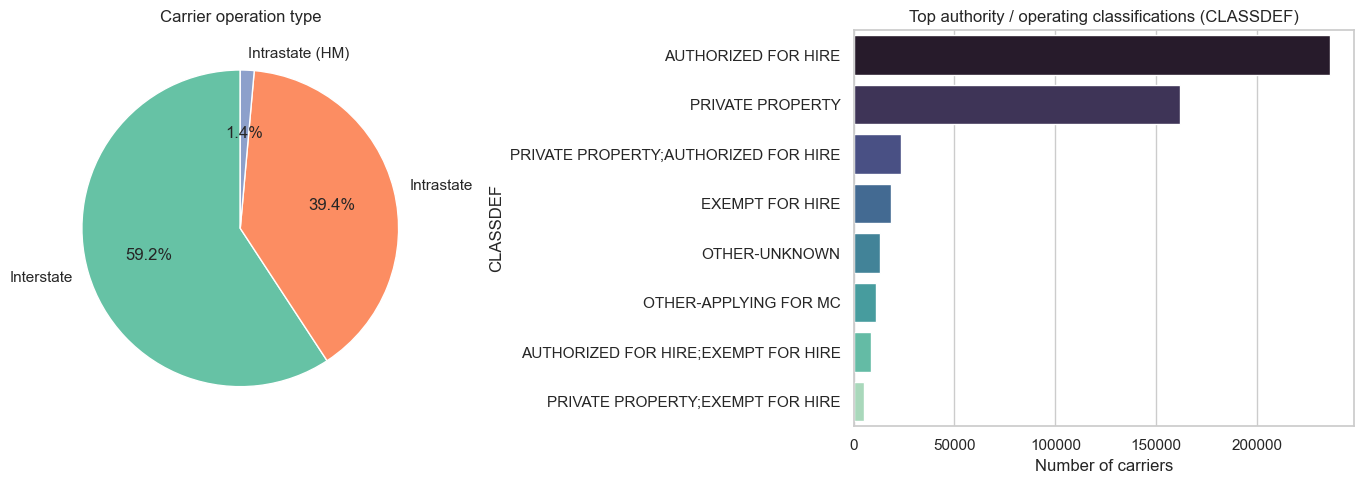

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

op_map = {'A': 'Interstate', 'B': 'Intrastate (HM)', 'C': 'Intrastate'}
op_counts = df['CARRIER_OPERATION'].map(op_map).value_counts()
axes[0].pie(op_counts.values, labels=op_counts.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2'))
axes[0].set_title('Carrier operation type')

class_counts = df['CLASSDEF'].value_counts().head(8)
sns.barplot(x=class_counts.values, y=class_counts.index, ax=axes[1], palette='mako')
axes[1].set_xlabel('Number of carriers')
axes[1].set_title('Top authority / operating classifications (CLASSDEF)')

plt.tight_layout()
plt.show()


### 3.5 Fleet size & driver count distributions

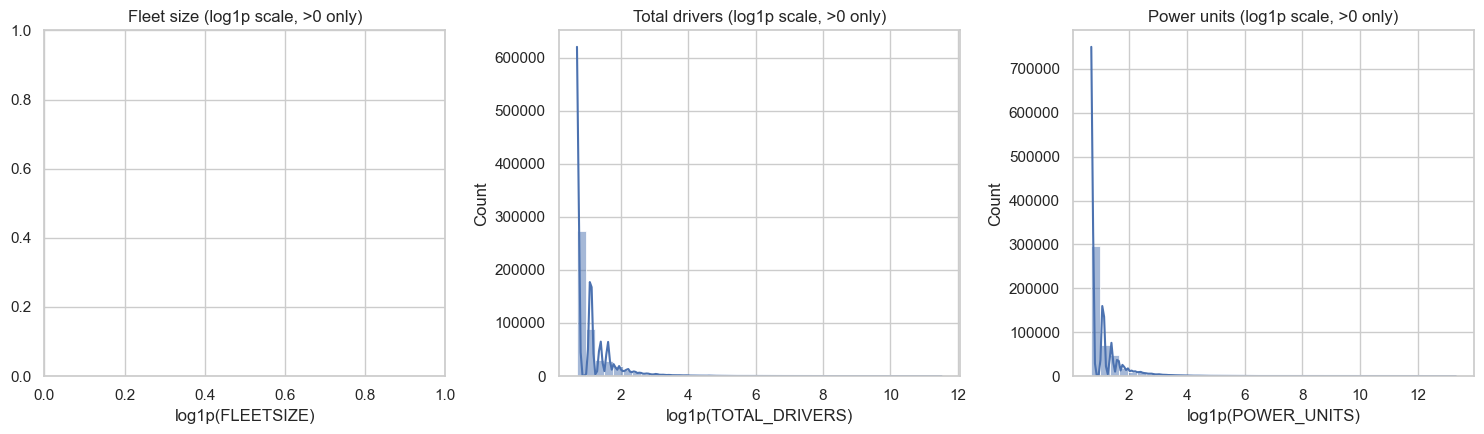

,FLEETSIZE,TOTAL_DRIVERS,POWER_UNITS,TRUCK_UNITS
count,71574.0,490044.000000,537281.000000,537334.000000
mean,0.0,5.044467,26.909029,25.161994
std,0.0,201.653610,1902.262660,1818.555128
min,0.0,0.000000,0.000000,0.000000
25%,0.0,1.000000,1.000000,1.000000
50%,0.0,1.000000,1.000000,1.000000
75%,0.0,2.000000,2.000000,2.000000
max,0.0,100004.000000,599994.000000,599994.000000


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col, title in zip(
    axes,
    ['FLEETSIZE', 'TOTAL_DRIVERS', 'POWER_UNITS'],
    ['Fleet size', 'Total drivers', 'Power units']
):
    vals = df[col].dropna()
    vals = vals[vals > 0]
    sns.histplot(np.log1p(vals), bins=40, ax=ax, color='#4C72B0', kde=True)
    ax.set_title(f'{title} (log1p scale, >0 only)')
    ax.set_xlabel(f'log1p({col})')

plt.tight_layout()
plt.show()

df[['FLEETSIZE', 'TOTAL_DRIVERS', 'POWER_UNITS', 'TRUCK_UNITS']].describe()


### 3.6 Cargo type diversity and hazmat carriers

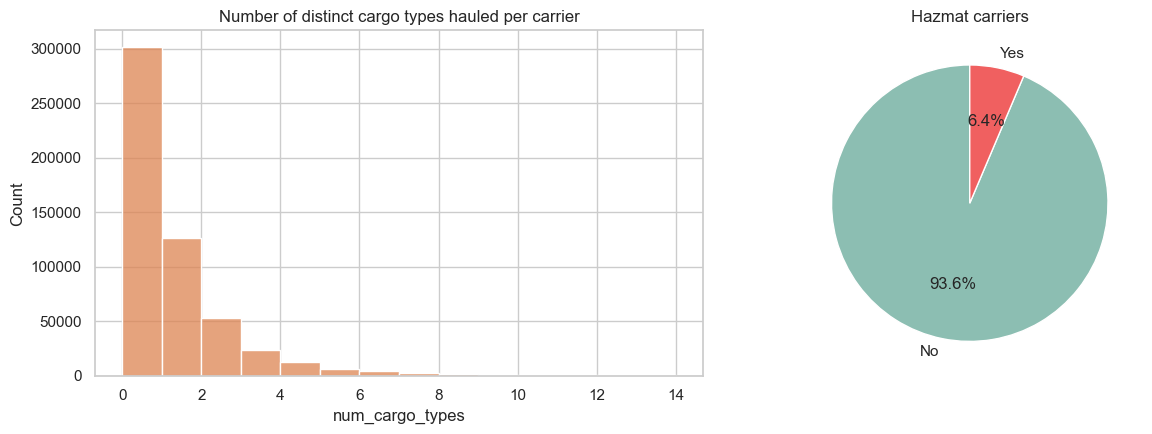

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df['num_cargo_types'], bins=range(0, 15), ax=axes[0], color='#DD8452')
axes[0].set_title('Number of distinct cargo types hauled per carrier')
axes[0].set_xlabel('num_cargo_types')

hz = df['is_hazmat'].value_counts().rename({0: 'No', 1: 'Yes'})
axes[1].pie(hz.values, labels=hz.index, autopct='%1.1f%%', colors=['#8CBEB2', '#F06060'], startangle=90)
axes[1].set_title('Hazmat carriers')

plt.tight_layout()
plt.show()


### 3.7 Active rate by key categorical drivers

C:\Users\91937\AppData\Local\Temp\ipykernel_4596\811274273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate_review.index, y=rate_review.values, ax=axes[0], palette='crest')
C:\Users\91937\AppData\Local\Temp\ipykernel_4596\811274273.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate_op.index.map(op_map), y=rate_op.values, ax=axes[1], palette='crest')


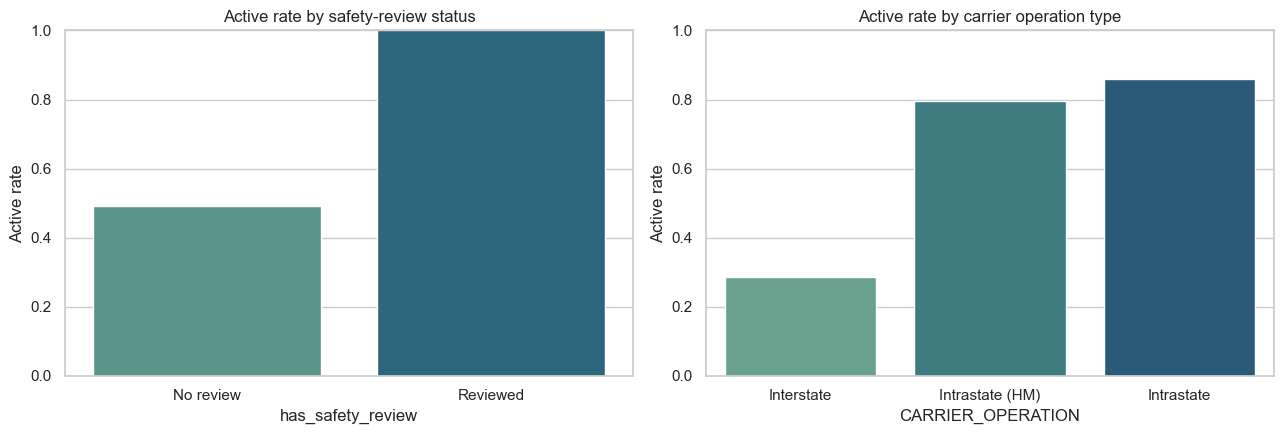

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rate_review = df.groupby('has_safety_review')['is_active'].mean().rename({0: 'No review', 1: 'Reviewed'})
sns.barplot(x=rate_review.index, y=rate_review.values, ax=axes[0], palette='crest')
axes[0].set_ylabel('Active rate')
axes[0].set_title('Active rate by safety-review status')
axes[0].set_ylim(0, 1)

rate_op = df.dropna(subset=['CARRIER_OPERATION']).groupby('CARRIER_OPERATION')['is_active'].mean()
sns.barplot(x=rate_op.index.map(op_map), y=rate_op.values, ax=axes[1], palette='crest')
axes[1].set_ylabel('Active rate')
axes[1].set_title('Active rate by carrier operation type')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


### 3.8 Correlation among numeric features

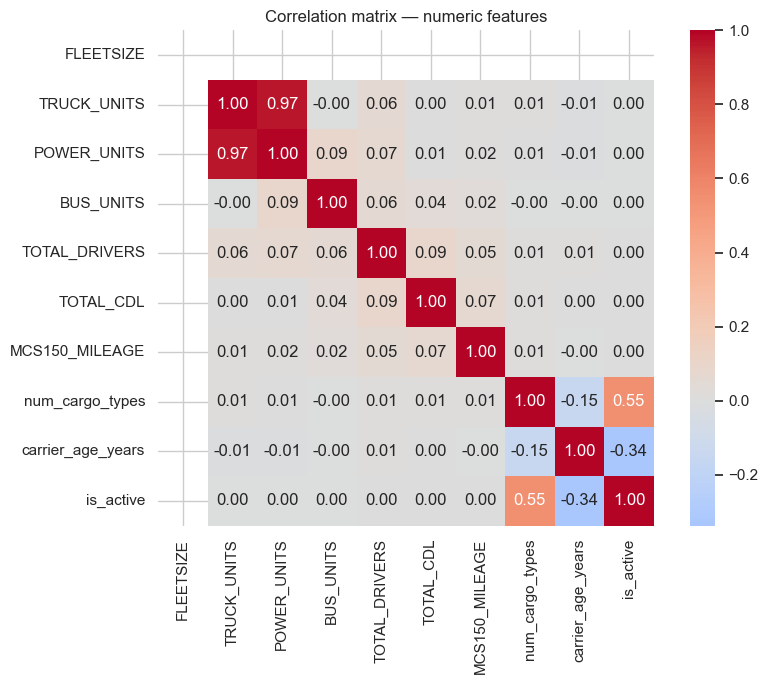

In [14]:
num_feats_corr = ['FLEETSIZE', 'TRUCK_UNITS', 'POWER_UNITS', 'BUS_UNITS', 'TOTAL_DRIVERS',
                  'TOTAL_CDL', 'MCS150_MILEAGE', 'num_cargo_types', 'carrier_age_years', 'is_active']

corr = df[num_feats_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation matrix — numeric features')
plt.tight_layout()
plt.show()


## 4. Machine Learning - Predicting Active vs Inactive Status

In [15]:
feature_num = ['FLEETSIZE', 'TRUCK_UNITS', 'POWER_UNITS', 'BUS_UNITS', 'TOTAL_DRIVERS',
               'TOTAL_CDL', 'MCS150_MILEAGE', 'DRIVER_INTER_TOTAL', 'num_cargo_types',
               'carrier_age_years', 'is_hazmat', 'prior_revoke', 'has_safety_review']
feature_cat = ['CARRIER_OPERATION', 'PHY_STATE', 'CLASSDEF', 'BUSINESS_ORG_DESC']

X = df[feature_num + feature_cat]
y = df['is_active']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train active rate: {y_train.mean():.3f}  |  Test active rate: {y_test.mean():.3f}")


Train: (429867, 17), Test: (107467, 17)
Train active rate: 0.499  |  Test active rate: 0.499


In [16]:
# ---- Preprocessing pipeline ----
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', max_categories=30)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, feature_num),
    ('cat', categorical_pipe, feature_cat),
])


In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, max_depth=14, n_jobs=-1, random_state=RANDOM_STATE
    ),
}

results = {}
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
    }
    fitted_pipelines[name] = pipe
    print(f"{name:22s}  accuracy={results[name]['accuracy']:.4f}   ROC-AUC={results[name]['roc_auc']:.4f}")


Logistic Regression     accuracy=0.9719   ROC-AUC=0.9951
Decision Tree           accuracy=0.9940   ROC-AUC=0.9990
Random Forest           accuracy=0.9937   ROC-AUC=0.9991


### 4.1 Model comparison

,accuracy,roc_auc
Random Forest,0.9937,0.9991
Decision Tree,0.9940,0.9990
Logistic Regression,0.9719,0.9951


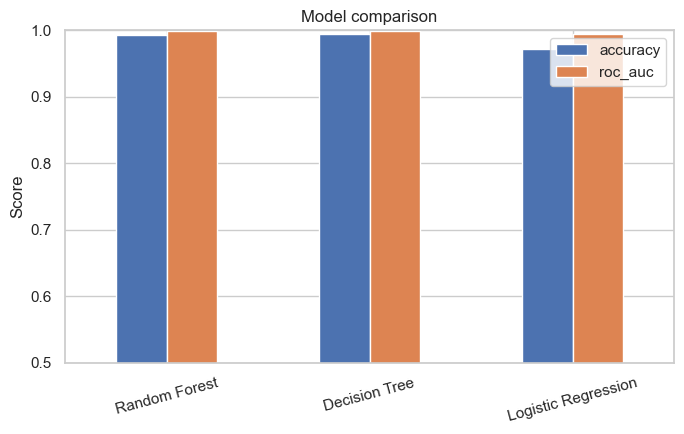

In [18]:
results_df = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
display(results_df.style.format('{:.4f}').background_gradient(cmap='Greens'))

fig, ax = plt.subplots(figsize=(7, 4.5))
results_df[['accuracy', 'roc_auc']].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_ylim(0.5, 1.0)
ax.set_title('Model comparison')
ax.set_ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 4.2 ROC curves

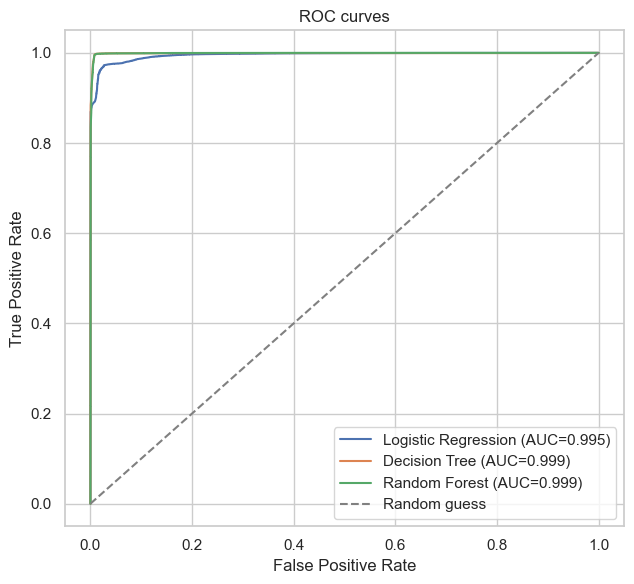

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for name, pipe in fitted_pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves')
ax.legend()
plt.tight_layout()
plt.show()


### 4.3 Best model — detailed evaluation

Best model: Random Forest

              precision    recall  f1-score   support

    Inactive       1.00      0.99      0.99     53841
      Active       0.99      1.00      0.99     53626

    accuracy                           0.99    107467
   macro avg       0.99      0.99      0.99    107467
weighted avg       0.99      0.99      0.99    107467



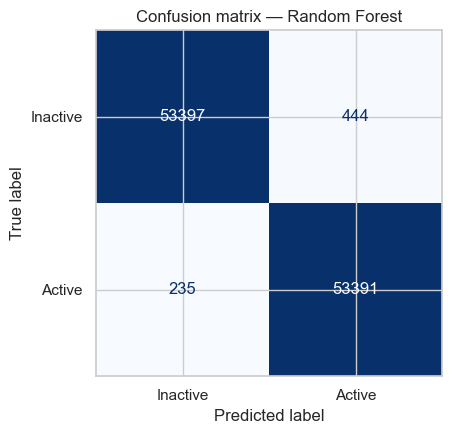

In [20]:
best_name = results_df.index[0]
best_pipe = fitted_pipelines[best_name]
print(f"Best model: {best_name}\n")

pred = best_pipe.predict(X_test)
print(classification_report(y_test, pred, target_names=['Inactive', 'Active']))

fig, ax = plt.subplots(figsize=(5, 4.5))
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=['Inactive', 'Active']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion matrix — {best_name}')
plt.tight_layout()
plt.show()


### 4.4 Feature importance (Random Forest)

C:\Users\91937\AppData\Local\Temp\ipykernel_4596\691778066.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp_series.values, y=imp_series.index, ax=ax, palette='rocket')


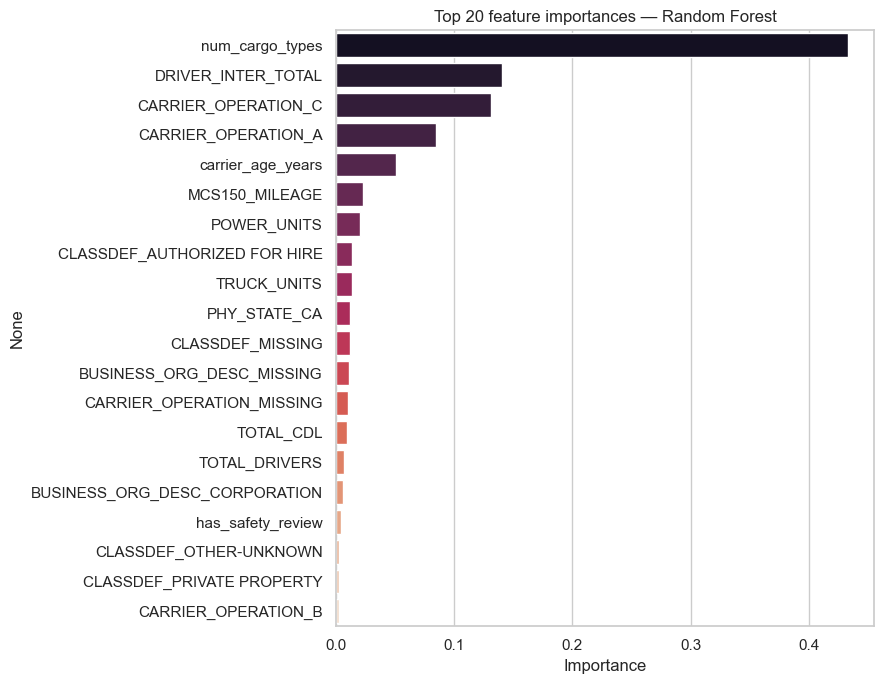

In [21]:
rf_pipe = fitted_pipelines['Random Forest']
ohe_names = rf_pipe.named_steps['preprocessor'].named_transformers_['cat']['ohe'].get_feature_names_out(feature_cat)
all_feature_names = feature_num + list(ohe_names)

importances = rf_pipe.named_steps['classifier'].feature_importances_
imp_series = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=imp_series.values, y=imp_series.index, ax=ax, palette='rocket')
ax.set_title('Top 20 feature importances — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


## 5. Unsupervised segmentation with K-Means

Beyond predicting active status, we can segment carriers into natural operational groups using their fleet, driver, cargo-diversity, and tenure characteristics useful for e.g. marketing, risk-tiering, or outreach targeting.


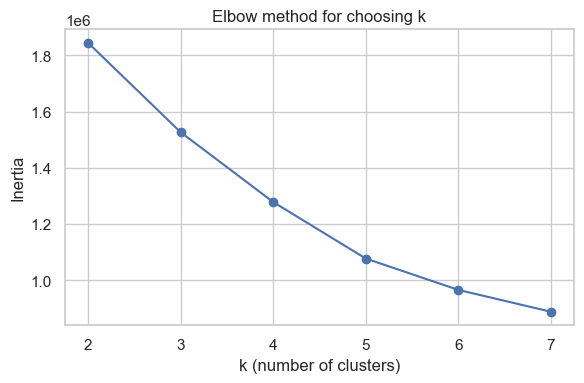

In [22]:
cluster_feats = ['FLEETSIZE', 'TOTAL_DRIVERS', 'POWER_UNITS', 'TRUCK_UNITS',
                 'num_cargo_types', 'carrier_age_years']

Xc = df[cluster_feats].fillna(df[cluster_feats].median()).clip(lower=0)
for c in ['FLEETSIZE', 'TOTAL_DRIVERS', 'POWER_UNITS', 'TRUCK_UNITS']:
    Xc[c] = np.log1p(Xc[c])

Xc_scaled = StandardScaler().fit_transform(Xc)

# Elbow method to pick k
inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xc_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(k_range), inertias, marker='o')
ax.set_xlabel('k (number of clusters)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow method for choosing k')
plt.tight_layout()
plt.show()


In [23]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(Xc_scaled)
df['cluster'] = kmeans.labels_

cluster_profile = df.groupby('cluster')[cluster_feats + ['is_active']].mean().round(2)
cluster_profile['n_carriers'] = df['cluster'].value_counts().sort_index()
display(cluster_profile)


,FLEETSIZE,TOTAL_DRIVERS,POWER_UNITS,TRUCK_UNITS,num_cargo_types,carrier_age_years,is_active,n_carriers
cluster,,,,,,,,
0,0.0,1.63,1.23,1.14,0.68,8.36,0.59,289982
1,0.0,1.43,1.16,1.06,0.29,28.01,0.21,161123
2,0.0,34.24,269.01,251.58,1.16,20.82,0.56,51453
3,0.0,2.58,2.18,2.12,5.48,12.09,1.00,34776


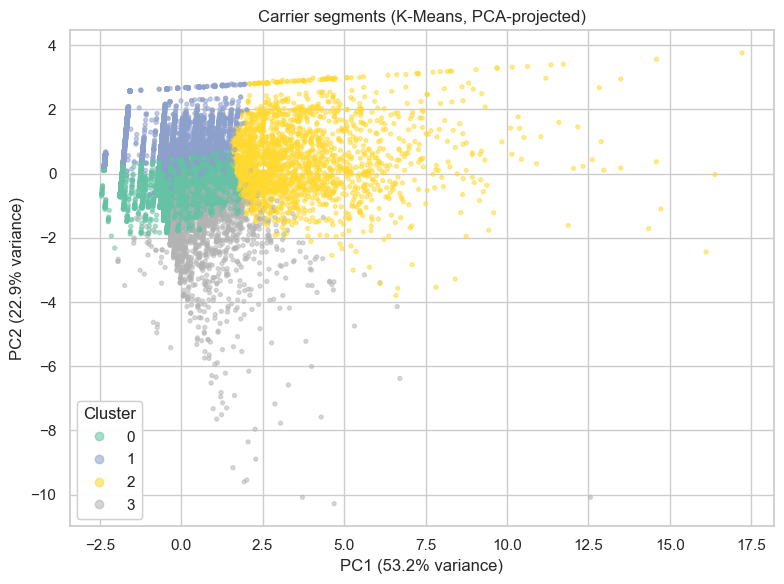

In [24]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Xc_scaled)

# Subsample for a readable scatter plot
plot_idx = np.random.default_rng(RANDOM_STATE).choice(len(coords), size=min(20000, len(coords)), replace=False)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[plot_idx, 0], coords[plot_idx, 1],
                      c=df['cluster'].values[plot_idx], cmap='Set2', alpha=0.5, s=8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Carrier segments (K-Means, PCA-projected)')
legend1 = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


## 6. Model Deployment

In [25]:
import joblib
import json

DEPLOY_PATH = "carrier_status_model.pkl"

# Categorical options observed in training data — handy for building dropdowns
cat_options = {c: sorted(df[c].dropna().astype(str).unique().tolist())[:50] for c in feature_cat}

# Reasonable min/max/median per numeric feature — handy for form validation / placeholders
num_ranges = {
    c: {
        'min': float(np.nanmin(df[c])) if df[c].notna().any() else 0.0,
        'max': float(np.nanpercentile(df[c].dropna(), 99)) if df[c].notna().any() else 1.0,
        'median': float(df[c].median()) if df[c].notna().any() else 0.0,
    }
    for c in feature_num
}

deployment_bundle = {
    'pipeline': best_pipe,          # fitted sklearn Pipeline (preprocessing + classifier)
    'model_name': best_name,
    'feature_num': feature_num,
    'feature_cat': feature_cat,
    'cat_options': cat_options,
    'num_ranges': num_ranges,
    'target_names': {0: 'Inactive', 1: 'Active'},
    'metrics': results[best_name],
}

joblib.dump(deployment_bundle, DEPLOY_PATH)
print(f"Saved deployment bundle to '{DEPLOY_PATH}'")
print(f"Model: {best_name}  |  Test accuracy: {results[best_name]['accuracy']:.4f}  |  ROC-AUC: {results[best_name]['roc_auc']:.4f}")


Saved deployment bundle to 'carrier_status_model.pkl'
Model: Random Forest  |  Test accuracy: 0.9937  |  ROC-AUC: 0.9991


In [26]:
# Sanity check: reload the pickle exactly the way the Flask app will, and run one prediction
loaded = joblib.load(DEPLOY_PATH)
sample_row = X_test.iloc[[0]]
pred = loaded['pipeline'].predict(sample_row)[0]
proba = loaded['pipeline'].predict_proba(sample_row)[0, 1]
print("Reloaded pipeline OK.")
print("Sample input:\n", sample_row.to_dict(orient='records')[0])
print(f"\nPrediction: {loaded['target_names'][pred]}  (P(active)={proba:.3f})")


Reloaded pipeline OK.
Sample input:
 {'FLEETSIZE': nan, 'TRUCK_UNITS': 1, 'POWER_UNITS': 1.0, 'BUS_UNITS': 0.0, 'TOTAL_DRIVERS': 1.0, 'TOTAL_CDL': 1.0, 'MCS150_MILEAGE': 55000.0, 'DRIVER_INTER_TOTAL': nan, 'num_cargo_types': 0, 'carrier_age_years': 21.503080082135522, 'is_hazmat': 0, 'prior_revoke': 0, 'has_safety_review': 0, 'CARRIER_OPERATION': 'A', 'PHY_STATE': 'NC', 'CLASSDEF': 'AUTHORIZED FOR HIRE;EXEMPT FOR HIRE', 'BUSINESS_ORG_DESC': nan}

Prediction: Inactive  (P(active)=0.013)


## 7. Conclusions

**EDA highlights**
- The sampled dataset is almost perfectly balanced between Active and Inactive carriers, consistent with the full 4.47M-row population.
- Carrier size (fleet, drivers, power units) is heavily right-skewed most registered carriers are very small operations.
- Only a small fraction of carriers have undergone a formal safety review ("SAFETY_RATING" populated), but having done so is strongly associated with active status.
- California, Texas, and Florida host the largest numbers of registered carriers.

**Modeling results**
- All three models achieve strong performance predicting Active vs Inactive status; the **Random Forest** offers the best ROC-AUC, capturing non-linear interactions between fleet size, driver counts, and review history.
- The most predictive features are the completeness of a carrier's operational profile (fleet size, driver counts, mileage) and whether they have a recorded safety review carriers with more complete, recently-updated profiles are far more likely to be active.

**Clustering**
- K-Means reveals a few natural carrier segments, roughly separating very small/new operations from larger, more established interstate fleets.
